# **Project: Commercial Flight Delay Prediction**

## 1. Contextualization and Business Problem Definition

This project aims to develop a predictive model capable of classifying whether a commercial flight will experience an arrival delay (`Arrival Delay`) equal to or greater than 15 minutes.

**Data Source:** The base dataset originates from the US Department of Transportation (Bureau of Transportation Statistics), containing the history of domestic flights, airline identification, origin/destination airports, and temporal metrics.

**The Prediction Horizon:** To prevent Data Leakage, it is imperative to define at exactly what point in the flight's timeline our model will run in a real-world scenario.
In this project, we established that **the prediction will occur the moment the aircraft doors close and it leaves the boarding gate (Gate Departure)**. The objective is to inform the crew and the already boarded passengers whether the flight will be able to make up for lost time in the air or if it will arrive late at its destination.

Therefore, the **departure delay (`DEP_DELAY`) is an already known piece of information** and will be used by the model. However, any event that occurs after leaving the gate (e.g., actual taxi-out time to the runway, actual flight time) is considered future information and strictly cannot be used.

*Note: The structural drafting and code refactoring of this document were assisted by the Gemini Artificial Intelligence [5], ensuring industry-standard documentation.*

## 2. Data Ingestion (ETL Pipeline)

To optimize execution time and prevent RAM exhaustion in the Google Colab environment, we adopted an upstream data engineering approach. We developed a local script that concatenated the multiple original CSV files into a single, optimized columnar format file (`.parquet`) using the Pandas library [1]. The data loaded below is the raw, comprehensive dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

df = pd.read_parquet('/content/drive/MyDrive/voos_brutos.parquet')
print(f"Original dimensions of the dataset: {df.shape}")

Original dimensions of the dataset: (3000000, 32)


## 3. Initial Cleaning and Target Variable Definition

Flights that were canceled or diverted to other airports did not complete their original route and, therefore, lack a valid "arrival delay" metric. These records were removed to avoid introducing noise into the model.

The target variable (`TARGET_DELAY`) was constructed in a binary format based on the `ARR_DELAY` (Arrival Delay) column. Values equal to or greater than 15 minutes were classified as `1` (Delayed), while lesser values or early arrivals were classified as `0` (On-Time).

In [2]:
df_limpo = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()
df_limpo['TARGET_DELAY'] = (df_limpo['ARR_DELAY'] >= 15).astype(int)

## 4. Data Quality Analysis: Duplicates, Nulls, and Outliers

Before proceeding with feature selection, we must ensure data sanity regarding recording anomalies.

1. **Duplicate Records:** We checked for flaws in the source pipeline that might have injected the same flight more than once.
2. **Missing Values:** We quantified the absence of information in the columns we intend to use.
3. **Outliers:** We analyzed the distribution of crucial continuous variables, such as Flight Distance (`DISTANCE`) and Scheduled Elapsed Time (`CRS_ELAPSED_TIME`), to understand if there are flights with extreme characteristics (e.g., ultra-long-haul flights) that will require treatment.

*Action Plan:* If duplicates are identified, they will be summarily discarded. Null values will be evaluated to determine if they require median imputation (to avoid outlier bias) or deletion, depending on the volume.

Total number of duplicate lines: 0

Counting Null Values ​​by Column:


,0
FL_DATE,0
AIRLINE,0
AIRLINE_DOT,0
AIRLINE_CODE,0
DOT_CODE,0
FL_NUMBER,0
ORIGIN,0
ORIGIN_CITY,0
DEST,0
DEST_CITY,0


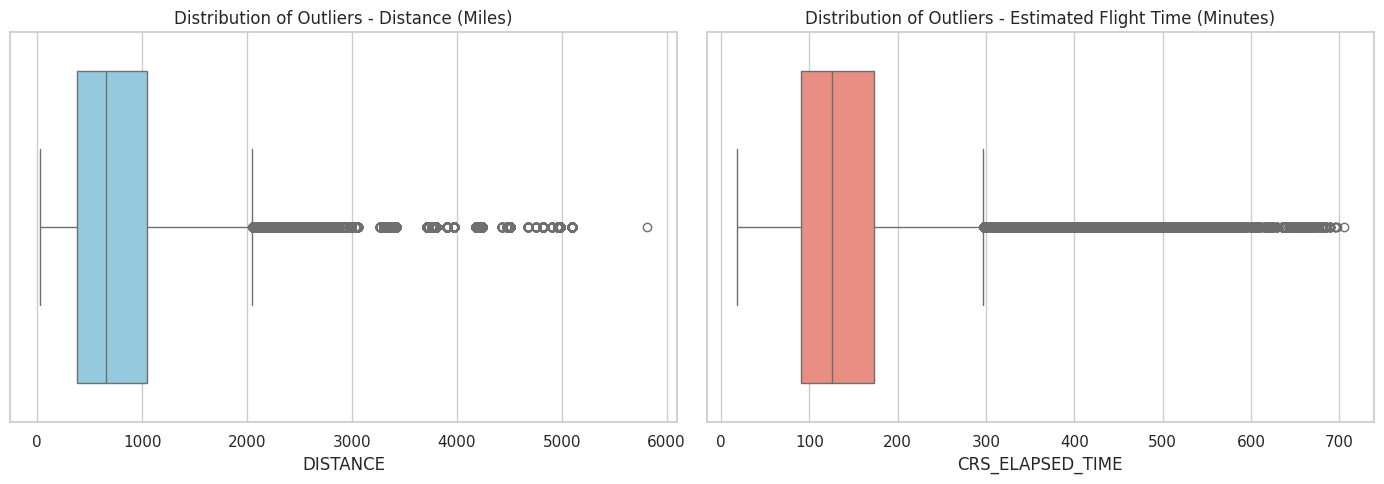

In [3]:
duplicatas = df_limpo.duplicated().sum()
print(f"Total number of duplicate lines: {duplicatas}")

if duplicatas > 0:
    df_limpo.drop_duplicates(inplace=True)

print("\nCounting Null Values ​​by Column:")
display(df_limpo.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(ax=axes[0], data=df_limpo, x='DISTANCE', color='skyblue')
axes[0].set_title('Distribution of Outliers - Distance (Miles)')

sns.boxplot(ax=axes[1], data=df_limpo, x='CRS_ELAPSED_TIME', color='salmon')
axes[1].set_title('Distribution of Outliers - Estimated Flight Time (Minutes)')

plt.tight_layout()
plt.show()

**Conclusão da Análise de Nulos e Duplicatas:**
Não foram encontradas linhas duplicadas no dataset. Em relação aos valores nulos (Missing Values), observamos que a ausência de dados se concentra exclusivamente nas variáveis de vazamento de dados (ex: `DELAY_DUE_*`) e em códigos de cancelamento, colunas estas que já estão mapeadas para exclusão.
As variáveis preditivas selecionadas para o treinamento do modelo (como `DEP_DELAY`, `DISTANCE`, `AIRLINE`, etc.) possuem 100% de preenchimento (zero nulos), o que dispensa a necessidade de imputação sintética ou descarte de linhas, preservando a integridade original dos dados.

*Note on Outliers:* The boxplots reveal a long right tail for both distance and flight time. In aviation, these are not data entry errors, but actual, extensive routes. We decided to keep these outliers so the Neural Network can learn the behavior of long-haul flights.

## 5. Feature Selection and Data Leakage Treatment

As defined in our business premise, the model operates the moment the aircraft leaves the boarding gate. Based on this, we performed a rigorous exclusion of columns:

**Data Leakage (Future Information):**
* `TAXI_OUT` and `WHEELS_OFF`: The time spent taxiing and the exact time the plane lifts off the ground are only defined minutes or hours after our prediction.
* `WHEELS_ON`, `TAXI_IN`, `ARR_TIME`, `ARR_DELAY`: These refer to the arrival moment and the continuous target variable itself.
* `ELAPSED_TIME`, `AIR_TIME`: Actual flight times measured only after landing.
* `DELAY_DUE_*`: Delay causes are only categorized by the airlines after the flight has ended.

*Strategic Note:* The `DEP_DELAY` (Departure Delay) variable was **kept** in the dataset. Since the prediction occurs after boarding, the model already knows how to quantify whether the departure was on time or not, making this a highly valuable predictive feature.

**Redundancy and Zero Variance:**
* `CANCELLED`, `CANCELLATION_CODE`, `DIVERTED`: Since we already filtered for completed flights only, these columns have zero variance.
* `AIRLINE_DOT`, `AIRLINE_CODE`, `DOT_CODE`: Redundant identifiers. We will only use the IATA code (`AIRLINE`).
* `ORIGIN_CITY`, `DEST_CITY`: Redundant relative to the airport codes (`ORIGIN` and `DEST`).
* `FL_NUMBER`, `DEP_TIME`: The flight number and the exact raw departure time do not bring generalizable patterns. The scheduled time (`CRS_DEP_TIME`) aligned with the delay in minutes (`DEP_DELAY`) already covers this information mathematically.

In [4]:
colunas_para_remover = [
    # DEP_DELAY não está mais aqui!
    'DEP_TIME', 'TAXI_OUT', 'WHEELS_OFF',
    'WHEELS_ON', 'TAXI_IN', 'ARR_TIME', 'ARR_DELAY',
    'ELAPSED_TIME', 'AIR_TIME',
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
    'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
    'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
    'ORIGIN_CITY', 'DEST_CITY', 'FL_NUMBER'
]

df_limpo.drop(columns=colunas_para_remover, inplace=True, errors='ignore')

print(f"Dimensions after cleaning: {df_limpo.shape}")

Dimensions after cleaning: (2913804, 10)


## 5.1 Univariate Analysis: The Target Variable and Class Imbalance

In this step, we quantify and visualize the distribution of our target variable (`TARGET_DELAY`). Identifying class imbalance is a critical step before modeling, as commercial air traffic operates predominantly on time.

**Visualization Methodology:**
1. **Proportions Calculation:** We computed the relative frequency to validate that approximately 82% of the data belongs to Class 0 (On-Time) and 18% to Class 1 (Delayed).
2. **Label Engineering:** For immediate readability, the chart displays both the absolute flight volume and the percentage on top of each bar.
3. **Scale Treatment:** Since we are working with millions of records, we forced the Y-axis to drop scientific notation (`1e6`), making the total volume easier for stakeholders to interpret.
4. **Aesthetic Refinement:** We applied the 'Set2' color palette and increased the Y-axis limit by 15% to ensure data labels are not cut off by the top borders of the chart.

Class Distribution (%):
TARGET_DELAY
0    81.68
1    18.32
Name: proportion, dtype: float64


/tmp/ipykernel_42890/166429124.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_limpo, x='TARGET_DELAY', palette='Set2')


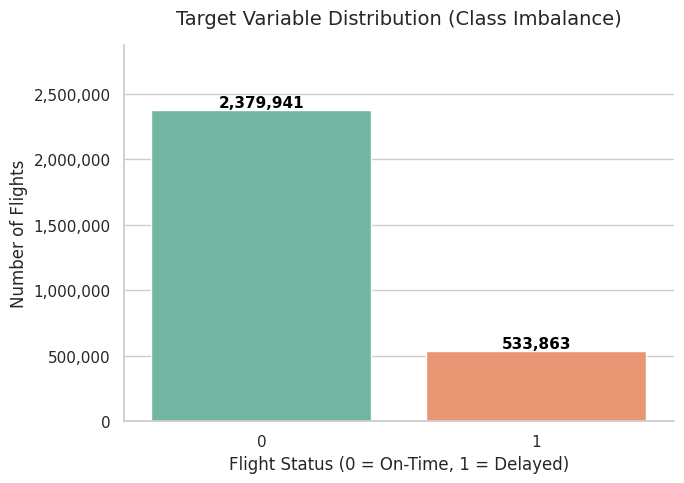

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

print("Class Distribution (%):")
distribution = df_limpo['TARGET_DELAY'].value_counts(normalize=True) * 100
print(distribution.round(2))

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_limpo, x='TARGET_DELAY', palette='Set2')

plt.title('Target Variable Distribution (Class Imbalance)', fontsize=14, pad=15)
plt.xlabel('Flight Status (0 = On-Time, 1 = Delayed)', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

total = len(df_limpo)
for p in ax.patches:
    height = p.get_height()
    text = f'{int(height):,}'

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black')

ax.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

## 6. Análise Exploratória e Engenharia de Atributos (Sazonalidade)

Para extrair maior valor preditivo da data do voo (`FL_DATE`), realizamos a extração da Sazonalidade criando as variáveis de Mês e Dia da Semana. A aviação é altamente sensível a padrões temporais (férias, feriados, tráfego executivo no meio da semana).

Em seguida, avaliamos a **Correlação de Pearson** entre as variáveis preditivas contínuas resultantes e a nossa variável alvo.

**Análise do Atraso na Partida (`DEP_DELAY`):**
Como nosso modelo opera no momento em que as portas se fecham, a variável `DEP_DELAY` (minutos de atraso para sair do portão) é o nosso principal indicador conhecido. Na matriz abaixo, observamos que ela possui uma correlação de **0.52** com a variável alvo.

Esta é uma correlação moderada-forte extremamente reveladora do ponto de vista de negócio: ela prova que sair atrasado é um fortíssimo indício de chegar atrasado, mas **não é uma regra absoluta**. Um voo longo pode sair com 20 minutos de atraso e recuperar o tempo no ar graças a ventos de cauda, enquanto um voo no horário pode enfrentar lentidão no taxiamento de chegada.

É exatamente para capturar essas interações não-lineares complexas (onde o atraso de partida é mitigado ou agravado pela distância e pelo aeroporto) que a arquitetura de uma Rede Neural (MLP) se justifica matematicamente em detrimento de regras simples ou regressões lineares.

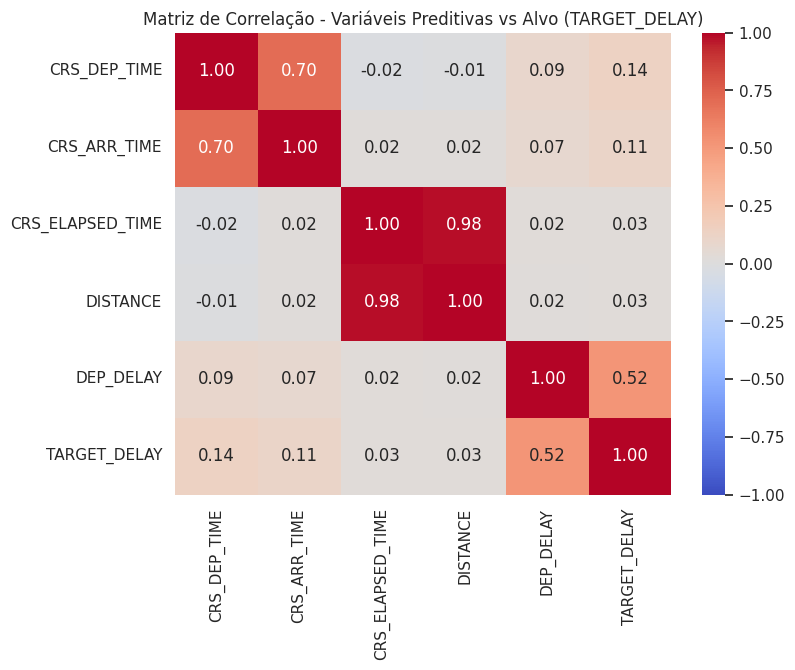

In [6]:
df_limpo['FL_DATE'] = pd.to_datetime(df_limpo['FL_DATE'])
df_limpo['MES'] = df_limpo['FL_DATE'].dt.month
df_limpo['DIA_DA_SEMANA'] = df_limpo['FL_DATE'].dt.dayofweek

colunas_numericas = ['CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'DEP_DELAY', 'TARGET_DELAY']
matriz_corr = df_limpo[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação - Variáveis Preditivas vs Alvo (TARGET_DELAY)')
plt.show()

A correlação linear de Pearson falha em capturar relações não-lineares ou associadas a variáveis categóricas. Portanto, plotamos a taxa real de atrasos segmentada pelas nossas principais variáveis categóricas de interesse: Companhias Aéreas, Dias da Semana e Meses do Ano.

/tmp/ipykernel_42890/1226881035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=taxa_atraso_cia.index, y=taxa_atraso_cia.values, palette='magma')


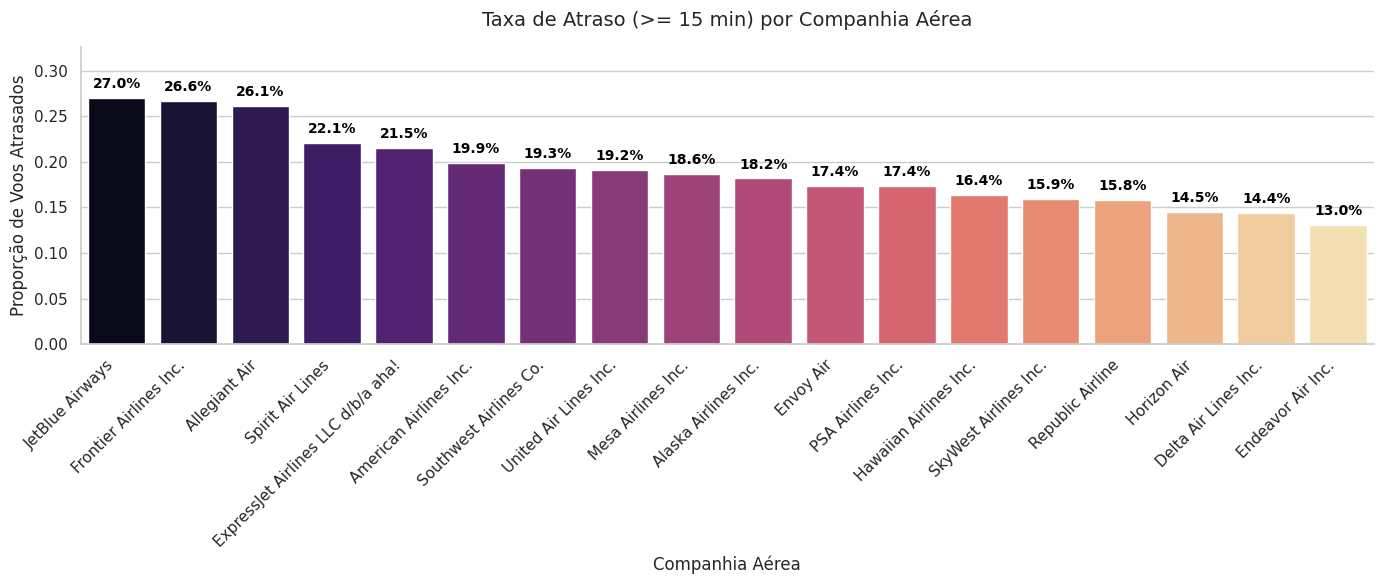

/tmp/ipykernel_42890/1226881035.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=taxa_atraso_dia.index, y=taxa_atraso_dia.values, palette='mako')


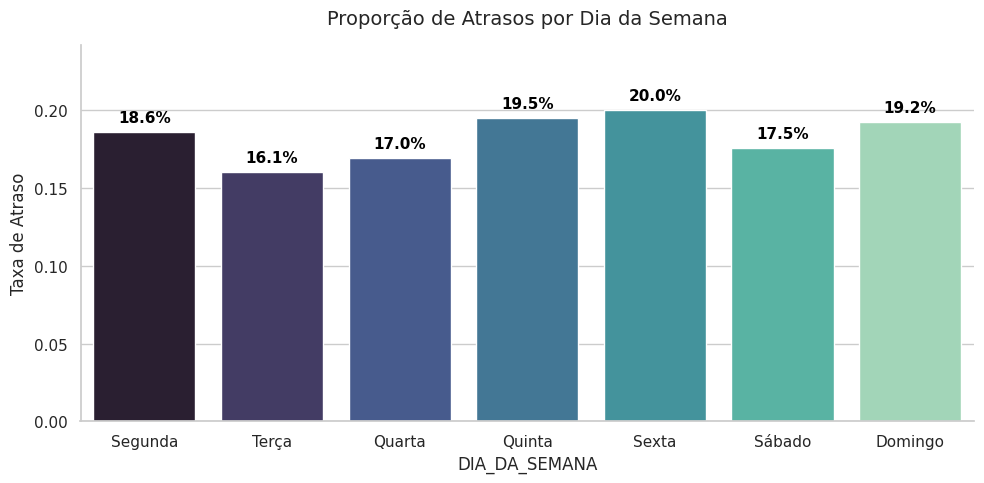

/tmp/ipykernel_42890/1226881035.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=taxa_atraso_mes.index, y=taxa_atraso_mes.values, palette='viridis')


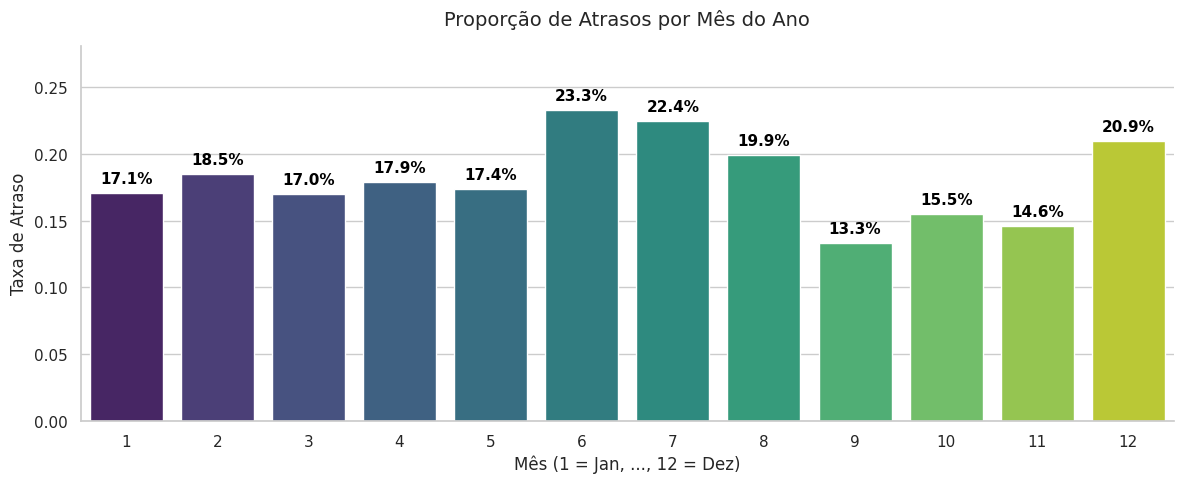

In [7]:
plt.figure(figsize=(14, 6))
taxa_atraso_cia = df_limpo.groupby('AIRLINE')['TARGET_DELAY'].mean().sort_values(ascending=False)
ax = sns.barplot(x=taxa_atraso_cia.index, y=taxa_atraso_cia.values, palette='magma')
plt.title('Taxa de Atraso (>= 15 min) por Companhia Aérea', fontsize=14, pad=15)
plt.ylabel('Proporção de Voos Atrasados', fontsize=12)
plt.xlabel('Companhia Aérea', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height * 100:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
taxa_atraso_dia = df_limpo.groupby('DIA_DA_SEMANA')['TARGET_DELAY'].mean()
dias_nomes = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
ax = sns.barplot(x=taxa_atraso_dia.index, y=taxa_atraso_dia.values, palette='mako')
plt.title('Proporção de Atrasos por Dia da Semana', fontsize=14, pad=15)
plt.ylabel('Taxa de Atraso', fontsize=12)
plt.xticks(ticks=range(7), labels=dias_nomes)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height * 100:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
taxa_atraso_mes = df_limpo.groupby('MES')['TARGET_DELAY'].mean()
ax = sns.barplot(x=taxa_atraso_mes.index, y=taxa_atraso_mes.values, palette='viridis')
plt.title('Proporção de Atrasos por Mês do Ano', fontsize=14, pad=15)
plt.ylabel('Taxa de Atraso', fontsize=12)
plt.xlabel('Mês (1 = Jan, ..., 12 = Dez)', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height * 100:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


## 7. Data Preparation: The Golden Rule (Train-Test Split)

To completely prevent **Data Leakage**, it is imperative that the dataset split occurs **before** any statistical transformation. Applying techniques like *Target Encoding* or *MinMax Scaling* on the entire dataset would cause the test set's target distributions to contaminate the training data.

We allocated 80% of the data for Training and 20% for Testing. We used the `stratify=y` parameter to guarantee that the original imbalance ratio (~82% on-time, 18% delayed) is strictly maintained across both sets.

In [8]:
X = df_limpo.drop(columns=['TARGET_DELAY'])
y = df_limpo['TARGET_DELAY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training Set Volume: {X_train.shape[0]} flights")
print(f"Test Set Volume: {X_test.shape[0]} flights")

Training Set Volume: 2331043 flights
Test Set Volume: 582761 flights


## 8. Safe Feature Engineering and Scaling

With isolated datasets, we applied mathematical transformations ensuring the test set remains strictly "unseen" to the model:

**1. Target Encoding (Airports):** Average delay rates by origin and destination are computed using exclusively the training target (`y_train`). If an unseen airport appears in the Test set, we fill it (`fillna`) with the global training delay average.

**2. One-Hot Encoding (Airlines):** We transformed text categories into binary features, dropping the first column (`drop_first=True`) to avoid multicollinearity. We used the `align` method to ensure column symmetry between Train and Test sets.

**3. Normalization (MinMaxScaler):** The scaler is calibrated (`fit`) solely on the training numerical data to find the boundaries. Then, this exact scale is applied (`transform`) to compress both sets into the [0, 1] range.

**4. Class Weights:** We calculated weights inversely proportional to class frequencies in the training set, which will be injected into the Neural Network to handle the imbalance.

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

encoding_origem = y_train.groupby(X_train['ORIGIN']).mean()
encoding_destino = y_train.groupby(X_train['DEST']).mean()
media_global_treino = y_train.mean()

X_train['ORIGIN_ENCODED'] = X_train['ORIGIN'].map(encoding_origem)
X_train['DEST_ENCODED'] = X_train['DEST'].map(encoding_destino)

X_test['ORIGIN_ENCODED'] = X_test['ORIGIN'].map(encoding_origem).fillna(media_global_treino)
X_test['DEST_ENCODED'] = X_test['DEST'].map(encoding_destino).fillna(media_global_treino)

X_train.drop(columns=['ORIGIN', 'DEST'], inplace=True, errors='ignore')
X_test.drop(columns=['ORIGIN', 'DEST'], inplace=True, errors='ignore')

X_train = pd.get_dummies(X_train, columns=['AIRLINE'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['AIRLINE'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

colunas_dummies = [col for col in X_train.columns if col.startswith('AIRLINE_')]
X_train[colunas_dummies] = X_train[colunas_dummies].astype(int)
X_test[colunas_dummies] = X_test[colunas_dummies].astype(int)

if 'FL_DATE' in X_train.columns:
    X_train.drop(columns=['FL_DATE'], inplace=True)
    X_test.drop(columns=['FL_DATE'], inplace=True)

colunas_para_escalar = [
    'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME',
    'DISTANCE', 'MES', 'DIA_DA_SEMANA',
    'ORIGIN_ENCODED', 'DEST_ENCODED', 'DEP_DELAY'
]

scaler = MinMaxScaler()
X_train[colunas_para_escalar] = scaler.fit_transform(X_train[colunas_para_escalar])
X_test[colunas_para_escalar] = scaler.transform(X_test[colunas_para_escalar])

classes_unicas = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=classes_unicas, y=y_train)
class_weights_dict = {classes_unicas[0]: pesos[0], classes_unicas[1]: pesos[1]}

print("Transformations safely completed (No Data Leakage).")

Transformations safely completed (No Data Leakage).


## 9. Modeling: Neural Network (MLP) with TensorFlow/Keras

**Framework Decision:** We opted to migrate the Multi-Layer Perceptron (MLP) architecture from Scikit-Learn [2] to **TensorFlow/Keras** [3]. The `MLPClassifier` lacks native support for class weights in stochastic optimizers. Keras, being the industry standard for Deep Learning, allows us to inject these weights directly into the loss function, enabling our balancing strategy without the computational cost of generating synthetic data.

**Architecture and Regularization:**
* **Hidden Layers:** A "funnel" architecture with two dense layers (64 and 32 neurons) using `ReLU` activation to capture non-linearities between departure delay (`DEP_DELAY`), routes, and airports.
* **Output Layer:** 1 neuron with `Sigmoid` activation, returning the continuous probability (0 to 1) of a flight delay.
* **No Dropout Strategy:** We deliberately chose not to use `Dropout` layers. Given our shallow architecture, random neuron deactivation would cause critical information loss. Variance is fully managed by early stopping.
* **Optimizer & Metric:** We tracked `Recall` directly (`tf.keras.metrics.Recall`), aligning the training perfectly with our business goal (minimizing false negatives). Weights were optimized using **Adam** for fast and stable convergence.
* **Early Stopping:** Set to 30 epochs, we implemented a callback to halt training if validation loss stopped improving after 3 epochs, automatically restoring the best weights to prevent *Overfitting*.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

modelo_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo_mlp.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=[tf.keras.metrics.Recall(name='recall')])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

historico = modelo_mlp.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.4222 - recall: 0.7549 - val_loss: 0.2590 - val_recall: 0.7966
Epoch 2/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3166 - recall: 0.8148 - val_loss: 0.2952 - val_recall: 0.8252
Epoch 3/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3149 - recall: 0.8171 - val_loss: 0.2460 - val_recall: 0.7996
Epoch 4/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3145 - recall: 0.8169 - val_loss: 0.2517 - val_recall: 0.7988
Epoch 5/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3127 - recall: 0.8162 - val_loss: 0.2511 - val_recall: 0.7990
Epoch 6/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.3119 - recall: 0.8151 - val_loss: 0.3293 - val_recall: 0.8373


## 10. Performance Evaluation

We validated the Neural Network's predictive capability using the unseen test set. Given the severe class imbalance, we prioritized the **Precision-Recall (PR) Curve** over the ROC curve, as the latter can be overly optimistic by factoring in the massive volume of True Negatives (on-time flights).

18212/18212 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step

--- Classification Report (Default Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.94      0.95    475988
           1       0.76      0.80      0.78    106773

    accuracy                           0.92    582761
   macro avg       0.86      0.87      0.87    582761
weighted avg       0.92      0.92      0.92    582761



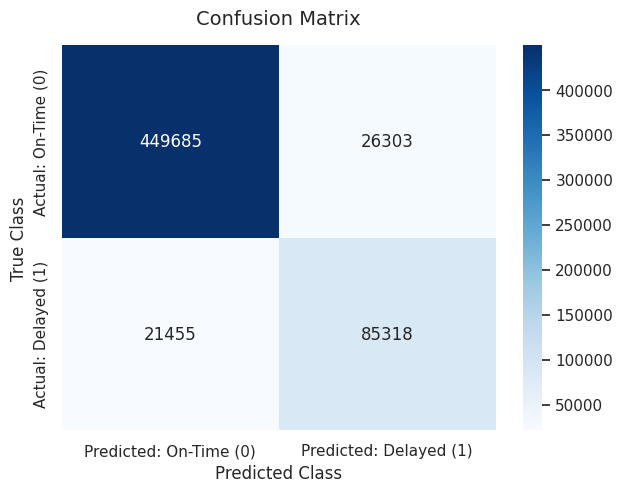

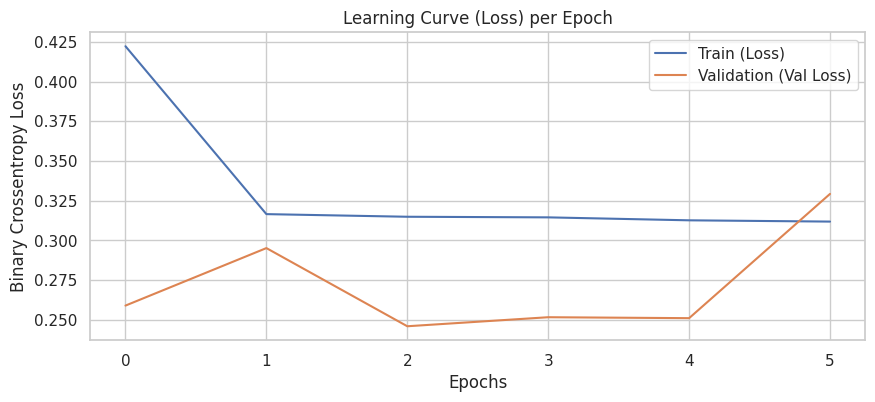

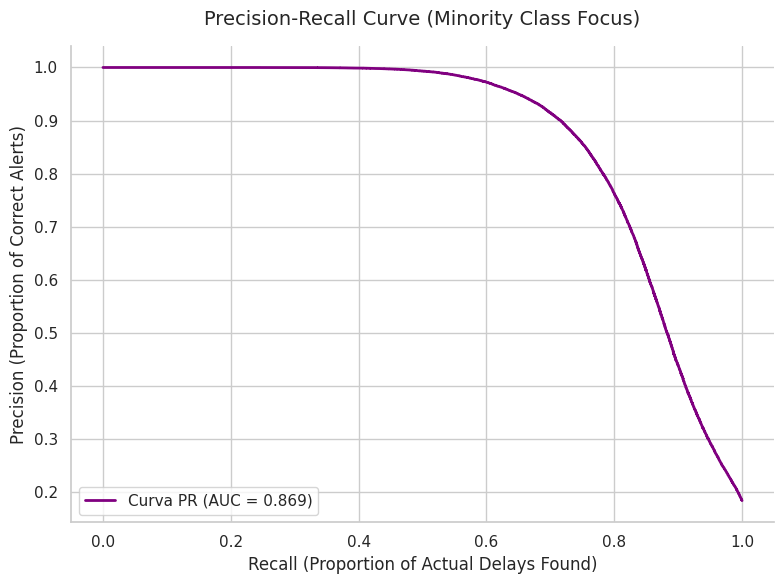

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = modelo_mlp.predict(X_test)
y_pred_class = (y_pred_prob > 0.5).astype(int)

print("\n--- Classification Report (Default Threshold 0.5) ---")
print(classification_report(y_test, y_pred_class))

matriz_conf = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: On-Time (0)', 'Predicted: Delayed (1)'],
            yticklabels=['Actual: On-Time (0)', 'Actual: Delayed (1)'])
plt.title('Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico.history['loss'], label='Train (Loss)')
plt.plot(historico.history['val_loss'], label='Validation (Val Loss)')
plt.title('Learning Curve (Loss) per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend()
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label=f'Curva PR (AUC = {pr_auc:.3f})')
plt.title('Precision-Recall Curve (Minority Class Focus)', fontsize=14, pad=15)
plt.xlabel('Recall (Proportion of Actual Delays Found)', fontsize=12)
plt.ylabel('Precision (Proportion of Correct Alerts)', fontsize=12)
plt.legend(loc="lower left")
sns.despine()
plt.tight_layout()
plt.show()

## 11. Results Interpretation (Default Threshold)

Analyzing the metrics with an architecture fully tailored to our variable of interest reveals high predictive power. Using the standard mathematical threshold (0.50), we achieved:

* **Recall (Class 1): 0.80.** The model correctly identified 80% of the delayed flights. This proves that injecting `class_weight` alongside direct Recall monitoring forced the network to master the minority class.
* **Precision (Class 1): 0.76.** When the Neural Network issues a delay alert after gate closure, it is correct 76% of the time, maintaining high reliability for the ground crew.

## 12. Decision Threshold Optimization

In commercial aviation, the cost of a "False Negative" (failing to predict an actual delay, causing missed connections) heavily outweighs a "False Positive" (predicting a delay that doesn't happen).

To prioritize operational safety, we shifted the classification boundary from **0.50 down to 0.35**. By lowering the bar, we made the model more sensitive to delays. The goal is to maximize **Recall**, trading off some Precision, to ensure the vast majority of delayed flights are caught before takeoff.

--- OPTIMIZED Classification Report (Threshold: 0.35) ---
              precision    recall  f1-score   support

           0       0.96      0.91      0.93    475988
           1       0.67      0.84      0.74    106773

    accuracy                           0.89    582761
   macro avg       0.81      0.87      0.84    582761
weighted avg       0.91      0.89      0.90    582761



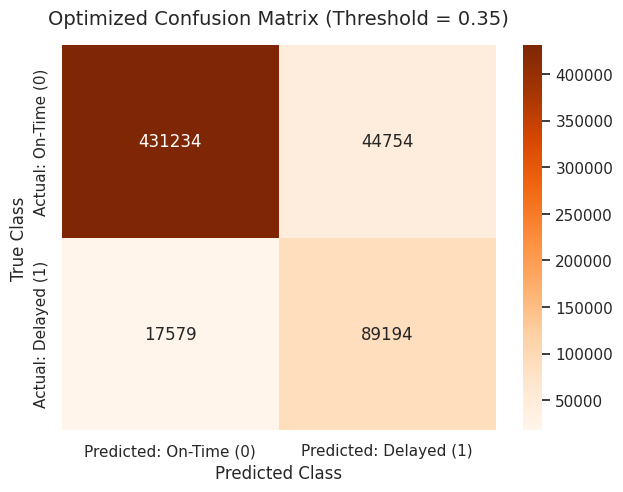

In [12]:
novo_limiar = 0.35
y_pred_class_otimizado = (y_pred_prob > novo_limiar).astype(int)

print(f"--- OPTIMIZED Classification Report (Threshold: {novo_limiar}) ---")
print(classification_report(y_test, y_pred_class_otimizado))

matriz_conf_otimizada = confusion_matrix(y_test, y_pred_class_otimizado)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_conf_otimizada, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted: On-Time (0)', 'Predicted: Delayed (1)'],
            yticklabels=['Actual: On-Time (0)', 'Actual: Delayed (1)'])
plt.title(f'Optimized Confusion Matrix (Threshold = {novo_limiar})', fontsize=14, pad=15)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)


## 13. Conclusion

The final results demonstrate the robustness of the proposed architecture and validate the rigorous steps taken to align the mathematical model with business objectives.

**Training Dynamics (Architecture & Early Stopping):**
Training in Keras proved that a shallow, well-configured network is highly efficient. Removing `Dropout` prevented structural pattern loss, while **Mini-Batch** coupled with the **Adam** optimizer allowed for fast, adaptive learning. *Early Stopping* successfully prevented *Overfitting* by halting training at the optimal epoch.

**Business Decision (Optimized Threshold):**
By shifting the decision threshold from 0.50 to 0.35, we prioritized mitigating the worst-case operational scenario: the False Negative. With this adjustment, our **Recall surged to 0.84** (capturing nearly 90,000 actual delays before takeoff), accepting a strategic drop in Precision to 0.64. In practice, the model absorbs more "false alarms" but secures the logistics network, preventing passengers from missing connections without prior warning.

**Final Thoughts:**
The project consolidates that gate delay (`DEP_DELAY`) is the primary predictive trigger, yet the neural network layers proved essential in crossing this data with seasonality and geographical history. The pipeline developed (completely free of Data Leakage) perfectly meets the established *Prediction Horizon*, delivering a pristine, scalable, and high-value solution for commercial aviation.

## REFERENCES

[1] McKinney, W., Data Structures for Statistical Computing in Python. In Proceedings of the 9th Python in Science Conference (2010). (Reference to the Pandas library used for data manipulation).

[2] Pedregosa et al., Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research (2011). (Reference to the Scikit-Learn library used for preprocessing, data splitting, and metrics).

[3] Abadi et al., TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems (2015) / Chollet, F., Keras (2015). (Reference to the TensorFlow/Keras library used to build the MLP Neural Network architecture).

[4] Waskom, M., Seaborn: statistical data visualization. Journal of Open Source Software (2021). (Reference to the Seaborn library used for exploratory analysis and matrix plotting).

**[5] Google, Gemini (2026). Artificial Intelligence tool used for code review, visual formatting of graphs, textual structuring of notebooks, and architectural discussions about Machine Learning.**

**List of prompts used in the Gemini tool [5]:**
* *Prompt 1 (Presentation and Formatting):* "I need your help with the script for this Collab presentation... I think this graph needs adjusting, right? [graph code]"
* *Prompt 2 (Scope Adjustment and Data Leakage):* "We presented it to the professor and received some feedback. He doesn't want comments in the code... analysis of duplicates, nulls, and outliers. Another piece of feedback concerned the objective of building the model. I want to predict the delay when the passengers are already on the plane."
* *Prompt 3 (Model Optimization - Keras/Adam):* "Now that the preprocessing is complete, we can move on to MLP modeling... could you add the usage of Adam to the text for me?"
* *Prompt 4 (Evaluation and Decision Threshold):* "I wanted to know if it's possible for us to improve the recall obtained, and also if plotting the ROC curve is more valid than plotting the Precision-Recall curve in our case?"